# Null models and permutation testing

We touched on null models briefly in [Notebook 1](intro01_spatial_colocalizations.ipynb) (conceptual background) and [Notebook 2](intro02_nispace_intro.ipynb) (where we called `permute("maps")` without much explanation). This notebook explains what's happening under the hood and when to use which approach.

There are two fundamentally different situations that call for different null models:

1. **You have a single group-level map** (e.g., the pain NeuroQuery map, a published effect size): permute the *reference maps*.
2. **You have individual subject data and a group design** (e.g., the anorexia nervosa dataset): permute the *group labels*.

For X-Set Enrichment Analysis, there's a third type — we'll cover that in [Notebook 10](intro10_xsea.ipynb).

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

# set up with the pain map
pet_maps = fetch_reference("pet", parcellation="Yan200",
                           collection="UniqueTracers", print_references=False)
pain_map = load_img("neuroquery/pain.nii.gz")

nsp = NiSpace(x=pet_maps, y=pain_map, y_labels="Pain",
              parcellation="Yan200", seed=42, n_proc=4)
nsp.fit()
nsp.colocalize("spearman")

INFO | 15/07/26 09:34:58 | nispace.datasets: Loading pet maps.


INFO | 15/07/26 09:34:58 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 15/07/26 09:34:58 | nispace.datasets: Filtering maps by collection.


INFO | 15/07/26 09:34:58 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 15/07/26 09:34:58 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 15/07/26 09:35:03 | nispace.api: Z-standardizing 'X' data.


INFO | 15/07/26 09:35:03 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 15/07/26 09:35:03 | nispace.api: Running 'spearman' colocalization.


INFO | 15/07/26 09:35:03 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2226.28it/s]

## Part 1: Surrogate map null models

When you call `permute("maps")`, NiSpace generates spatially-constrained random versions of the reference maps and recomputes the correlation with your input map for each permutation. The empirical distribution of these null correlations becomes the null distribution.

The null method is **auto-selected** based on the parcellation type — you can customize this, but usually should not need to.

- **Cortical-only parcellations**: Moran spectral randomization (`"moran"`) is chosen automatically
- **Combined (cx+sc) parcellations**: Split Moran spectral randomization (`("moran", "moran")`) is chosen automatically — cortex and subcortex are treated independently

Several methods are available (more are continuously added):

| Method | Key idea | When selected |
|--------|----------|---------------|
| `"moran"` / `"brainspace"` | Moran spectral randomization: Randomize spectral coefficients of the spatial covariance | **Auto-default** for cortical-only parcellations |
| `("moran", "moran")` | Split Moran: run independently on cortex and subcortex | **Auto-default** for combined (cx+sc) parcellations |
| `"cornblath"` / `"spin"` | Fractional transition spin: for each rotation, the null map value at parcel *i* is a weighted average over all parcels that received its vertices. | Cortical-only parcellations; explicit choice |
| `"baum"` | Vertex-level rotation + modal parcel assignment | Alternative spin; explicit choice |
| `"alexander_bloch"` | Original nearest-centroid spin (Alexander-Bloch et al. 2018) | Alternative spin; explicit choice |
| `"vasa"` | As in the Alexander-Bloch method, but exact reassignments instead of nearest-centroid | Alternative spin; explicit choice |
| `"hungarian"` | As in the Alexander-Bloch method, but hungarian matching instead of nearest-centroid | Alternative spin; explicit choice |
| `"burt2020"` / `"brainsmash"` / `"variogram"` | Auto-regressive model to match data-distance relationship | Explicit choice; any parcellation |
| `"burt2018"` | Match the spatial variogram of the original map | Explicit choice; any parcellation |

### Moran Spectral Randomization (moran)

Moran spectral randomization decomposes the spatial covariance structure of the parcellation into eigenvectors (Moran eigenvectors), then randomizes the spectral coefficients while preserving the overall structure. The result is a null map with the same degree of spatial autocorrelation, but with the specific spatial pattern scrambled.

Two key properties:
1. **Works with any parcellation geometry** — subcortical structures, volumetric atlases, anything.
2. **No precomputed matrix needed** — eigenvectors are derived on the fly from the parcellation distance matrix.

Moran is auto-selected for cortical-only parcellations like Yan200:

In [4]:
# moran is auto-selected for all parcellations, so null_method can be omitted
nsp.permute("maps", n_perm=1000, p_tails="upper")
p_moran = nsp.get_p_values()
print("Moran spectral — 5 lowest p-values:")
p_moran.T.sort_values(by="Pain").head(5)

INFO | 15/07/26 09:35:06 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 15/07/26 09:35:06 | nispace.api: Permutation of: X maps.


INFO | 15/07/26 09:35:06 | nispace.api: Using default null method 'moran' (parcellation null space: 'fsLR').


INFO | 15/07/26 09:35:06 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 15/07/26 09:35:06 | nispace.api: Loading observed colocalizations (method = 'spearman').


...

Processing null arrays (4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 936.90it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8986.57it/s]

INFO | 15/07/26 09:35:11 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Moran spectral — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.057
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.095
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.146
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.199
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.247


### The spin test (cornblath)

For cortical-only parcellations with a surface space (fsLR, fsaverage), an alternative is the spin test. A commonly used spin method is `"cornblath"` (Cornblath et al., 2020), as recommended by [Markello & Misic (2021)](https://markello-spatialnulls.netlify.app/recommendations).

The spin test works by projecting the cortical parcellation onto a sphere and applying random rotations. This preserves the spatial topology of the original map while breaking any specific spatial relationship with the input map.

We implement the method via a **fractional transition matrix**: for each random rotation, it records what fraction of each parcel's surface vertices land in each other parcel. The null map value for parcel *i* is then a weighted average over all parcels that received its vertices. This implementation has the big advantage that the transition matrices can be stored and re-applied. For all included cortical parcellations, NiSpace automatically downloads 10,000 of these matrices, reducing computation time to a few seconds. The alias `"spin"` maps to `"cornblath"` — they are identical.

To use the spin test, pass `maps_method="cornblath"` explicitly:

In [5]:
nsp.permute("maps", maps_method="cornblath", n_perm=1000, p_tails="upper")
p_spin = nsp.get_p_values()
print("Cornblath spin — 5 lowest p-values:")
p_spin.T.sort_values(by="Pain").head(5)

INFO | 15/07/26 09:35:11 | nispace.core.permute: Found existing null maps.


WARNING | 15/07/26 09:35:11 | nispace.core.permute: Null method changed. Will re-generate.


INFO | 15/07/26 09:35:11 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'cornblath').


INFO | 15/07/26 09:35:11 | nispace.nulls: Null map generation: Assuming n = 29 data vector(s) for n = 200 parcels.


INFO | 15/07/26 09:35:11 | nispace.nulls: Using provided precomputed Cornblath transition matrix.


...

Processing null arrays (4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6550.85it/s]

Null colocalizations (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 12781.82it/s]

INFO | 15/07/26 09:35:14 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Cornblath spin — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.039
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.058
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.114
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.124
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.257


In [6]:
# compare spin and Moran side by side
comparison = pd.DataFrame({
    "rho": nsp.get_colocalizations().T["Pain"],
    "p_spin": p_spin.T["Pain"],
    "p_moran": p_moran.T["Pain"],
}).sort_values("p_spin")
comparison.head(10)

,,rho,p_spin,p_moran
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.422783,0.039,0.057
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.335397,0.058,0.095
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.288889,0.114,0.247
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.273213,0.124,0.146
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.180214,0.257,0.199
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.171576,0.258,0.256
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.145715,0.272,0.281
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.097589,0.336,0.340
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.107938,0.354,0.373


### Combined parcellations: split Moran on cortex and subcortex

For combined (cortex + subcortex) parcellations, the spin test cannot cover the whole brain — subcortical structures have no spherical surface projection. NiSpace's default for combined parcellations is therefore **split Moran spectral randomization (`("moran", "moran")`)** — running independently on the cortical and subcortical components using their respective distance matrices.

**Why split?** Many reference maps and input maps have a cortical-subcortical gradient. If nulls were generated on the full combined distance matrix (whole-brain Moran), this gradient would be scrambled in the nulls — inflating the effective variance and making the test more conservative. Generating nulls separately for cortex and subcortex preserves the value distributions within each compartment, retaining the overall gradient and producing better-calibrated tests.

> **Are you testing spatial correlations beyond a cortex-subcortex gradient, or is the alignment between these compartments itself part of your hypothesis?** If cortex-subcortex alignment is part of the signal you want to test, use whole-brain `"moran"` instead.

| `maps_method` | Notes |
|---------------|-------|
| `("moran", "moran")` | **Auto-default** for combined parcellations; split Moran on cx and sc dist_mats |
| `"moran"` | Whole-brain Moran on full combined dist_mat; explicit choice |
| `("cornblath", "moran")` | Split: spin for cortex, Moran for subcortex; explicit choice |
| `("baum", "moran")` | Alternative spin for cortex |
| `("alexander_bloch", "moran")` | Legacy spin variant |
| `("cornblath", "burt2020")` | Variogram for subcortex |
| `"burt2020"` | BrainSmash variogram on full combined dist_mat |
| `"burt2018"` | Burt 2018 method on full combined dist_mat |

The subcortex position of split methods only accepts non-spin options (`"moran"`, `"burt2020"`, `"burt2018"`).

In [7]:
from nispace.datasets import fetch_reference as _fr

# load PET maps for combined parcellation
pet_combined = _fr("pet", parcellation="Yan200+TianS1",
                   collection="UniqueTracers", print_references=False)

nsp_combined = NiSpace(x=pet_combined, y=pain_map, y_labels="Pain",
                       parcellation="Yan200+TianS1", seed=42, n_proc=4)
nsp_combined.fit()
nsp_combined.colocalize("spearman")

# auto-selects ("moran", "moran") — split Moran on cortex and subcortex separately
nsp_combined.permute("maps", n_perm=500, p_tails="upper")
p_combined = nsp_combined.get_p_values()
print("Combined parcellation (moran+moran, default) — 5 lowest p-values:")
p_combined.T.sort_values(by="Pain").head(5)

INFO | 15/07/26 09:35:14 | nispace.datasets: Loading pet maps.


INFO | 15/07/26 09:35:14 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 15/07/26 09:35:14 | nispace.datasets: Filtering maps by collection.


INFO | 15/07/26 09:35:14 | nispace.datasets: Loading and inner-merging data parcellated with 'Yan200' and 'TianS1'


INFO | 15/07/26 09:35:14 | nispace.core.parcellation: Building combined Parcellation 'Yan200+TianS1' from library.


...

Processing null arrays (4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 4197.49it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 8095.33it/s]

INFO | 15/07/26 09:35:17 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Combined parcellation (moran+moran, default) — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.034
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.120
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.184
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.210
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.232


## Part 2: Group permutation

When you have individual subject data and a group comparison design, permuting the reference maps isn't quite right — you should permute the group labels instead. The logic is:

> If the colocalization between the patient effect size map and a reference map is real, then randomly reassigning subjects to groups should produce smaller effect sizes, and hence smaller colocalizations.

This is implemented with `permute("groups")`. We use the anorexia nervosa example dataset below.

> **Note:** This dataset is **simulated** and not intended for scientific use.

In [8]:
# set up with the anorexia nervosa dataset
an_data = fetch_example("anorexianervosa", parcellation="Yan200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

nsp_groups = NiSpace(x=pet_maps, y=an_data, parcellation="Yan200",
                     seed=42, n_proc=4)
nsp_groups.fit()

# compute effect sizes first
nsp_groups.transform_y(transform="hedges(a,b)", groups=groups)
nsp_groups.colocalize("spearman")

# group permutation: randomly shuffle the AN/HC labels and recompute
nsp_groups.permute(
    "groups",
    groups=groups,
    n_perm=1000, # increase to >=10000 for final analyses
    p_tails="two"  # two-tailed: we don't have a directional hypothesis here
)
p_groups = nsp_groups.get_p_values()
y_label = p_groups.index[0]
print(f"Group permutation ({y_label}) — 5 lowest p-values:")
p_groups.T.sort_values(by=y_label).head(5)

INFO | 15/07/26 09:35:17 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Yan200.


INFO | 15/07/26 09:35:17 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 15/07/26 09:35:17 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 15/07/26 09:35:18 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 15/07/26 09:35:18 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


...

Processing null arrays (4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4137.92it/s]

Null colocalizations (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 15932.17it/s]

INFO | 15/07/26 09:35:19 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Group permutation (hedges) — 5 lowest p-values:


hedges
set       map                                                       
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...   0.001
Dopamine  target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...   0.001
          target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...   0.004
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012     0.008
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...   0.018

### Which null model should I use?

A practical guide:

| Situation | Recommended null model |
|-----------|------------------------|
| Single cortical map (published effect size, meta-analytic map) | `permute("maps")` — `"moran"` auto-selected for all cortical atlases (e.g., Yan200) |
| Single map with combined (cx+sc) parcellation | `permute("maps")` — `("moran", "moran")` auto-selected (split: cx and sc treated independently) |
| Single map with volumetric-only parcellation | `permute("maps")` — `"moran"` auto-selected |
| Individual subject data with group comparison | `permute("groups")` |
| XSEA (set enrichment) | `permute("maps")` by default — see [Notebook 10](intro10_xsea.ipynb) |

Group permutation is more computationally expensive (the effect size must be recomputed for each permutation) but is more appropriate when you have individual-level data.

## Part 3: Visualizing the null distribution

After calling `permute()`, the null distribution is stored internally and used when you call `nsp.plot()`. The grey shading in the plot represents the null distribution percentiles.

INFO | 15/07/26 09:35:20 | nispace.plotting: Significance annotation: 1/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


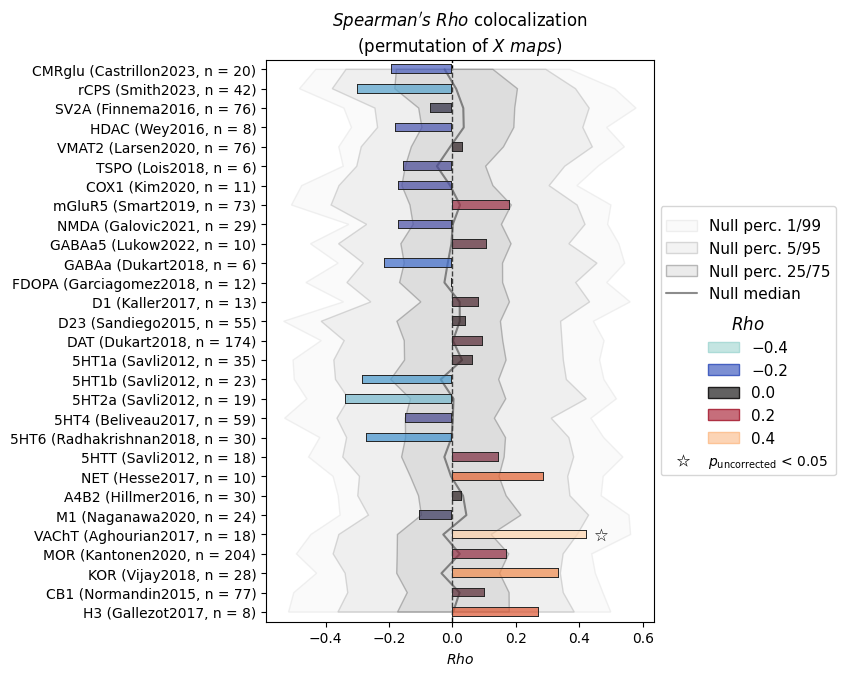

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x3b3f72310>)

In [9]:
# correct p values
nsp.correct_p()
# plot with null distribution shading
nsp.plot()

## Summary

- `permute("maps")` without specifying `null_method` — auto-selects `"moran"` for cortical-only, `("moran", "moran")` for combined (cx+sc) parcellations
- `permute("maps", null_method="moran")` — Moran spectral randomization; for combined parcellations, treats cx+sc as one region (whole-brain); explicit override
- `permute("maps", null_method=("moran", "moran"))` — split Moran; **auto-default** for combined parcellations; cx and sc treated independently
- `permute("maps", null_method="cornblath")` — fractional transition spin; alias: `"spin"`; explicit choice for cortical parcellations
- `permute("maps", null_method="baum")` — modal parcel assignment spin; alternative to cornblath
- `permute("maps", null_method="alexander_bloch")` — original nearest-centroid spin; legacy
- `permute("maps", null_method="burt2020")` — variogram matching; works with any parcellation
- `permute("maps", null_method=("cornblath", "moran"))` — explicit split for combined parcellations (cx=cornblath, sc=moran)
- `permute("groups", groups=...)` — group label permutation; preferred for individual subject data
- All methods produce empirical p-values stored in the NiSpace object, retrievable with `get_p_values()`

Next: [Notebook 6](intro06_multiple_comparisons.ipynb) covers multiple comparisons correction — because running 29 receptor tests at once without correction is not a great idea.